# 第五讲：用 AKShare 下载沪深300 — 均线与波动率实战

**学习目标**
- 用 AKShare 下载真实金融数据
- 计算 5 / 20 / 60 日均线
- 计算滚动波动率（年化）
- 画出均线叠加图，一眼判断趋势
- 串联第四讲的缺失值处理、resample、rolling

---

In [3]:
# 如果还没装 akshare，取消下面这行的注释并运行

!pip install akshare -q

import akshare as ak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

%matplotlib inline
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

print(f"pandas: {pd.__version__}")
print(f"akshare: {ak.__version__}")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
pandas: 3.0.2
akshare: 1.18.64


## 5.1 下载沪深300指数日线数据

使用 AKShare 的 `stock_zh_index_daily` 接口，下载沪深300（代码 `sh000300`）的历史日线。

In [4]:
# 下载沪深300指数日线数据
# sh000300 = 沪深300, sz399001 = 深证成指, sh000001 = 上证综指
df = ak.stock_zh_index_daily(symbol="sh000300")

print(f"原始数据形状: {df.shape}")
print(f"列名: {df.columns.tolist()}")
print(f"日期范围: {df['date'].min()} ~ {df['date'].max()}")
df.head()

原始数据形状: (5916, 6)
列名: ['date', 'open', 'high', 'low', 'close', 'volume']
日期范围: 2002-01-04 ~ 2026-05-28


,date,open,high,low,close,volume
0,2002-01-04,1316.455,1316.455,1316.455,1316.455,0
1,2002-01-07,1302.084,1302.084,1302.084,1302.084,0
2,2002-01-08,1292.714,1292.714,1292.714,1292.714,0
3,2002-01-09,1272.645,1272.645,1272.645,1272.645,0
4,2002-01-10,1281.261,1281.261,1281.261,1281.261,0


## 5.2 数据清洗与预处理

AKShare 返回的数据需要做几步标准化处理才能用于分析：
1. 统一列名为英文（方便后续操作）
2. 将 date 列转为 DatetimeIndex
3. 按日期排序
4. 检查和处理缺失值

In [5]:
# 1. 统一列名
# AKShare 不同版本返回的列名可能略有不同，这里做一个兼容映射
col_map = {
    '日期': 'date', 'date': 'date',
    '开盘价': 'open', 'open': 'open',
    '最高价': 'high', 'high': 'high',
    '最低价': 'low', 'low': 'low',
    '收盘价': 'close', 'close': 'close',
    '成交量': 'volume', 'volume': 'volume',
    '成交额': 'amount', 'amount': 'amount',
}
# 只重命名存在的列
df = df.rename(columns={k: v for k, v in col_map.items() if k in df.columns})

# 2. date 列 → DatetimeIndex
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

# 3. 只保留需要的列
needed_cols = ['open', 'high', 'low', 'close', 'volume']
df = df[[c for c in needed_cols if c in df.columns]]

print(f"清洗后形状: {df.shape}")
print(f"索引类型: {type(df.index)}")
df.head()

清洗后形状: (5916, 5)
索引类型: <class 'pandas.DatetimeIndex'>


,open,high,low,close,volume
date,,,,,
2002-01-04,1316.455,1316.455,1316.455,1316.455,0
2002-01-07,1302.084,1302.084,1302.084,1302.084,0
2002-01-08,1292.714,1292.714,1292.714,1292.714,0
2002-01-09,1272.645,1272.645,1272.645,1272.645,0
2002-01-10,1281.261,1281.261,1281.261,1281.261,0


In [6]:
# 4. 检查缺失值（复习第四讲）
print("各列缺失值统计:")
print(df.isnull().sum())

print(f"\n缺失值总行数: {df.isnull().any(axis=1).sum()}")

# 如果有缺失值，用前向填充处理
if df.isnull().any().any():
    df = df.ffill()
    print("\n前向填充完成，剩余缺失值:")
    print(df.isnull().sum())

# 5. 数据概览
print("\n--- 数据概览 ---")
df.describe()

各列缺失值统计:
open      0
high      0
low       0
close     0
volume    0
dtype: int64

缺失值总行数: 0

--- 数据概览 ---


,open,high,low,close,volume
count,5916.000000,5916.000000,5916.000000,5916.000000,5.916000e+03
mean,3056.007045,3082.000727,3030.106354,3058.347285,9.638498e+09
std,1222.936160,1234.272146,1209.807110,1223.111872,8.494482e+09
min,816.546000,823.860000,807.784000,818.033000,0.000000e+00
25%,2231.336750,2251.735250,2208.231250,2235.700250,3.828506e+09
50%,3269.330000,3297.160000,3238.117000,3272.352000,8.263199e+09
75%,3909.573250,3938.869500,3881.926750,3912.025750,1.312269e+10
max,5922.071000,5930.912000,5815.609000,5877.202000,6.864391e+10


In [7]:
# 6. 异常值检查（复习第四讲 IQR 法）
Q1 = df['close'].quantile(0.25)
Q3 = df['close'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 3 * IQR  # 用 3 倍 IQR 更宽松，避免误杀正常波动
upper = Q3 + 3 * IQR

outliers = (df['close'] < lower) | (df['close'] > upper)
print(f"收盘价异常值检测 (3×IQR):")
print(f"  下界: {lower:.2f}, 上界: {upper:.2f}")
print(f"  异常值数量: {outliers.sum()}")
if outliers.sum() > 0:
    print(f"\n异常日期:\n{df[outliers][['close']]}")

收盘价异常值检测 (3×IQR):
  下界: -2793.28, 上界: 8941.00
  异常值数量: 0


## 5.3 计算均线（Moving Average）

均线是最经典的趋势跟踪指标：
- **5 日均线**：短线交易者的「心跳」，反映最近一周的趋势
- **20 日均线**：中线参考，约一个月的交易节奏
- **60 日均线**：长线方向，季线级别的大趋势

In [8]:
# 计算三条均线
df['MA5']  = df['close'].rolling(window=5).mean()
df['MA20'] = df['close'].rolling(window=20).mean()
df['MA60'] = df['close'].rolling(window=60).mean()

# 看一眼最近的数据
print("最近 10 个交易日（含均线）:")
df[['close', 'MA5', 'MA20', 'MA60']].tail(10)

最近 10 个交易日（含均线）:


,close,MA5,MA20,MA60
date,,,,
2026-05-15,4859.593,4934.4832,4825.00140,4684.448667
2026-05-18,4833.524,4910.8206,4832.41530,4686.356467
2026-05-19,4852.883,4891.7878,4838.22905,4688.499583
2026-05-20,4850.700,4862.2594,4844.33045,4690.780933
2026-05-21,4783.098,4835.9596,4845.61325,4691.839600
2026-05-22,4845.096,4833.0602,4849.46820,4694.917767
2026-05-25,4921.597,4850.6748,4855.56670,4698.485317
2026-05-26,4947.849,4869.6680,4863.64280,4702.018033
2026-05-27,4908.171,4881.1622,4870.58290,4705.039650


## 5.4 计算滚动波动率

波动率衡量价格的「摇晃程度」，是量化风控的核心指标。

**日波动率** = 日收益率的滚动标准差

**年化波动率** = 日波动率 × √252（252 ≈ 一年交易天数）

In [9]:
# 1. 计算日收益率（对数收益率）
df['return'] = np.log(df['close'] / df['close'].shift(1))

# 2. 计算滚动日波动率（20日窗口）
df['volatility_20d'] = df['return'].rolling(window=20).std()

# 3. 年化波动率
df['volatility_annual'] = df['volatility_20d'] * np.sqrt(252)

# 也计算一个 60 日的年化波动率作为对比
df['volatility_annual_60'] = df['return'].rolling(window=60).std() * np.sqrt(252)

print("波动率数据（最近10天）:")
df[['close', 'return', 'volatility_20d', 'volatility_annual']].tail(10)

波动率数据（最近10天）:


,close,return,volatility_20d,volatility_annual
date,,,,
2026-05-15,4859.593,-0.011255,0.008446,0.134078
2026-05-18,4833.524,-0.005379,0.008519,0.135238
2026-05-19,4852.883,0.003997,0.008256,0.131066
2026-05-20,4850.700,-0.000450,0.008238,0.130779
2026-05-21,4783.098,-0.014035,0.008828,0.140139
2026-05-22,4845.096,0.012879,0.009263,0.147045
2026-05-25,4921.597,0.015666,0.009769,0.155082
2026-05-26,4947.849,0.005320,0.009761,0.154954
2026-05-27,4908.171,-0.008052,0.009938,0.157760


## 5.5 画均线叠加图 🎨

这张图是技术分析中最经典的图表之一。直接用最近两年数据来画，信息密度刚好。

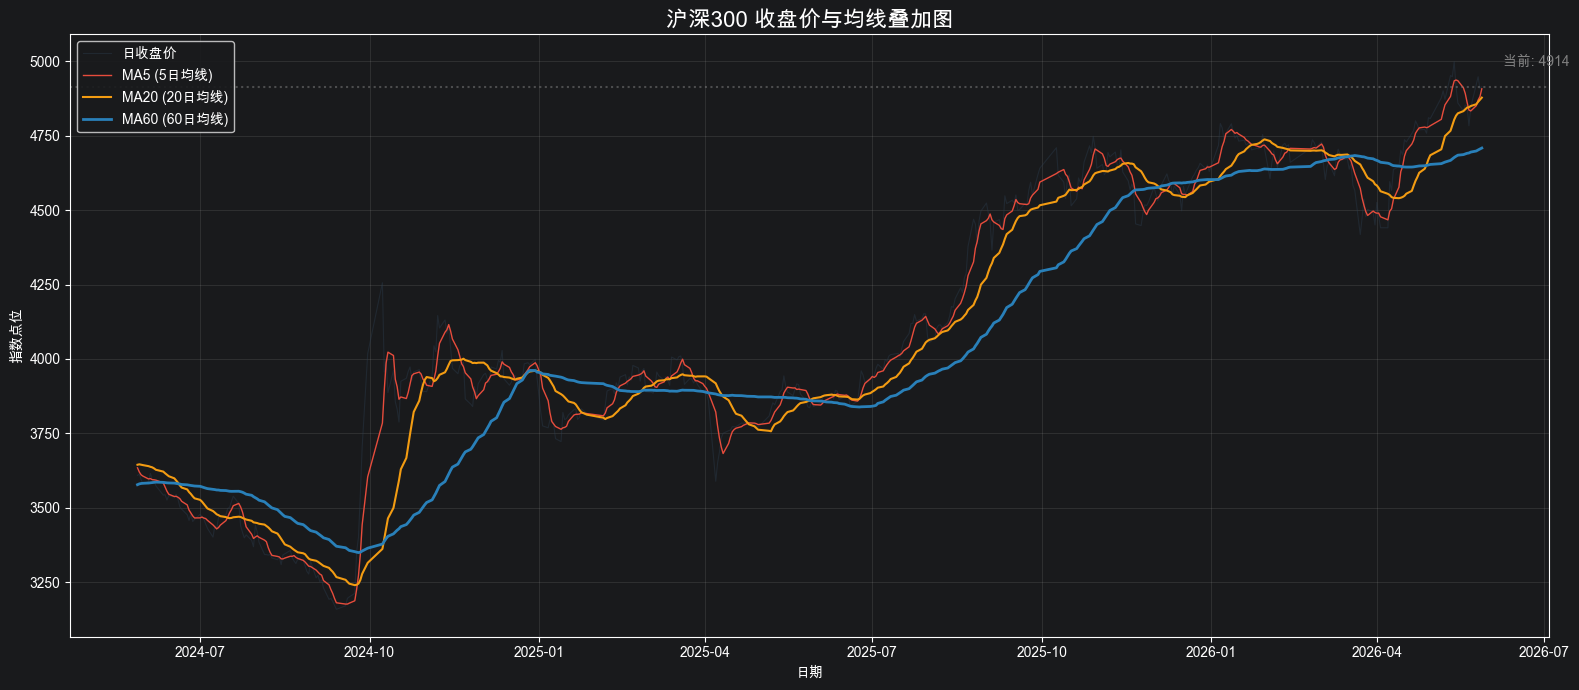

当前收盘价: 4914.21
MA5:   4907.39  ▲ 站上
MA20:  4877.75  ▲ 站上
MA60:  4708.43  ▲ 站上


In [11]:
# 取最近 2 年的数据画图（数据太多反而看不清）
recent = df[df.index >= df.index[-1] - pd.DateOffset(years=2)]

fig, ax = plt.subplots(figsize=(16, 7))

# 原始收盘价
ax.plot(recent.index, recent['close'], 
        color='#2c3e50', alpha=0.4, linewidth=0.8, label='日收盘价')

# 三条均线
ax.plot(recent.index, recent['MA5'],  
        color='#e74c3c', linewidth=1.0, label='MA5 (5日均线)')
ax.plot(recent.index, recent['MA20'], 
        color='#f39c12', linewidth=1.5, label='MA20 (20日均线)')
ax.plot(recent.index, recent['MA60'], 
        color='#2980b9', linewidth=2.0, label='MA60 (60日均线)')

# 标注：当前价格 vs 各均线
last_close = recent['close'].iloc[-1]
last_date = recent.index[-1]
ax.axhline(y=last_close, color='gray', linestyle=':', alpha=0.5)
ax.annotate(f'当前: {last_close:.0f}', 
            xy=(last_date, last_close),
            xytext=(15, 15), textcoords='offset points',
            fontsize=10, color='gray')

ax.set_title('沪深300 收盘价与均线叠加图', fontsize=16, fontweight='bold')
ax.set_xlabel('日期')
ax.set_ylabel('指数点位')
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# 打印关键参考
print(f"当前收盘价: {last_close:.2f}")
print(f"MA5:   {recent['MA5'].iloc[-1]:.2f}  {'▲ 站上' if last_close > recent['MA5'].iloc[-1] else '▼ 跌破'}")
print(f"MA20:  {recent['MA20'].iloc[-1]:.2f}  {'▲ 站上' if last_close > recent['MA20'].iloc[-1] else '▼ 跌破'}")
print(f"MA60:  {recent['MA60'].iloc[-1]:.2f}  {'▲ 站上' if last_close > recent['MA60'].iloc[-1] else '▼ 跌破'}")

### 均线图形怎么看？

- **多头排列**：MA5 > MA20 > MA60，且价格站上所有均线 → 上升趋势
- **空头排列**：MA5 < MA20 < MA60，且价格跌破所有均线 → 下降趋势
- **缠绕**：三条线纠缠在一起 → 震荡市，方向不明
- **金叉**：短期均线上穿长期均线 → 买入信号
- **死叉**：短期均线下穿长期均线 → 卖出信号

## 5.6 画滚动波动率图

波动率不是噪声——它是量化交易中最核心的信息之一。波动率上升 ≈ 市场恐慌，波动率下降 ≈ 市场平静。

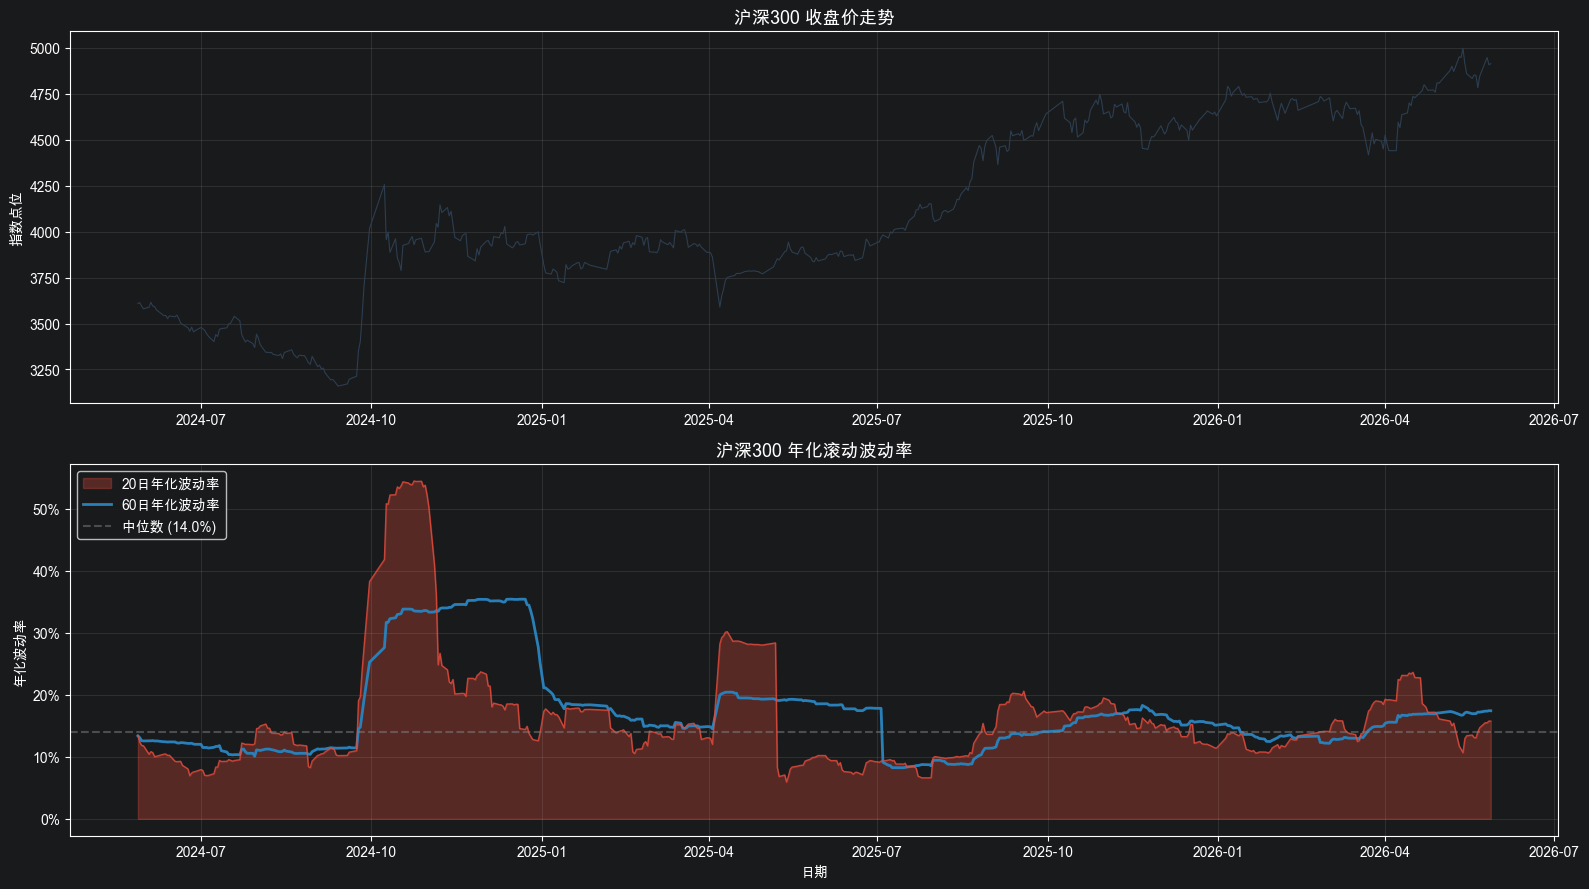

当前年化波动率: 15.8%
历史中位数:     14.0%
📊 当前波动率在正常范围内


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# 上图：收盘价走势
ax1 = axes[0]
ax1.plot(recent.index, recent['close'], color='#2c3e50', linewidth=0.8)
ax1.set_title('沪深300 收盘价走势', fontsize=13, fontweight='bold')
ax1.set_ylabel('指数点位')
ax1.grid(True, alpha=0.2)

# 下图：年化波动率
ax2 = axes[1]
ax2.fill_between(recent.index, 0, recent['volatility_annual'], 
                  alpha=0.3, color='#e74c3c', label='20日年化波动率')
ax2.plot(recent.index, recent['volatility_annual_60'], 
         color='#2980b9', linewidth=2, label='60日年化波动率')
ax2.plot(recent.index, recent['volatility_annual'], 
         color='#e74c3c', linewidth=1, alpha=0.8)

# 加上一条中位线作为参考
median_vol = recent['volatility_annual'].median()
ax2.axhline(y=median_vol, color='gray', linestyle='--', alpha=0.5,
            label=f'中位数 ({median_vol:.1%})')

ax2.set_title('沪深300 年化滚动波动率', fontsize=13, fontweight='bold')
ax2.set_xlabel('日期')
ax2.set_ylabel('年化波动率')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.legend(loc='upper left', framealpha=0.9)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# 打印当前波动率状态
current_vol = recent['volatility_annual'].iloc[-1]
print(f"当前年化波动率: {current_vol:.1%}")
print(f"历史中位数:     {median_vol:.1%}")
if current_vol > median_vol * 1.5:
    print("⚠️ 当前波动率偏高，市场处于高波动状态")
elif current_vol < median_vol * 0.5:
    print("💤 当前波动率偏低，市场处于低波动状态")
else:
    print("📊 当前波动率在正常范围内")

## 5.7 Bonus：金叉死叉信号识别

用 5 日均线和 20 日均线做一个简单的信号识别，初步感受一下量化策略的思路。

In [15]:
# 计算金叉/死叉信号
# 当 MA5 从下方上穿 MA20 → 金叉（买入信号）
# 当 MA5 从上方下穿 MA20 → 死叉（卖出信号）

recent = recent.copy()  # 避免 SettingWithCopyWarning

# 前一日的均线关系
recent['MA5_above_MA20'] = recent['MA5'] > recent['MA20']
recent['MA5_above_MA20_prev'] = recent['MA5_above_MA20'].shift(1)

# 金叉：昨天 MA5 ≤ MA20，今天 MA5 > MA20（fillna 处理 shift 产生的 NaN）
recent['golden_cross'] = (~recent['MA5_above_MA20_prev'].fillna(False)) & recent['MA5_above_MA20'].fillna(False)

# 死叉：昨天 MA5 ≥ MA20，今天 MA5 < MA20
recent['death_cross'] = recent['MA5_above_MA20_prev'].fillna(False) & (~recent['MA5_above_MA20'].fillna(False))

golden_dates = recent[recent['golden_cross']]
death_dates = recent[recent['death_cross']]

print(f"近2年金叉信号次数: {len(golden_dates)}")
print(f"近2年死叉信号次数: {len(death_dates)}")

if len(golden_dates) > 0:
    print(f"\n最近一次金叉: {golden_dates.index[-1].strftime('%Y-%m-%d')}")
if len(death_dates) > 0:
    print(f"最近一次死叉: {death_dates.index[-1].strftime('%Y-%m-%d')}")

近2年金叉信号次数: 17
近2年死叉信号次数: 16

最近一次金叉: 2026-05-26
最近一次死叉: 2026-05-21


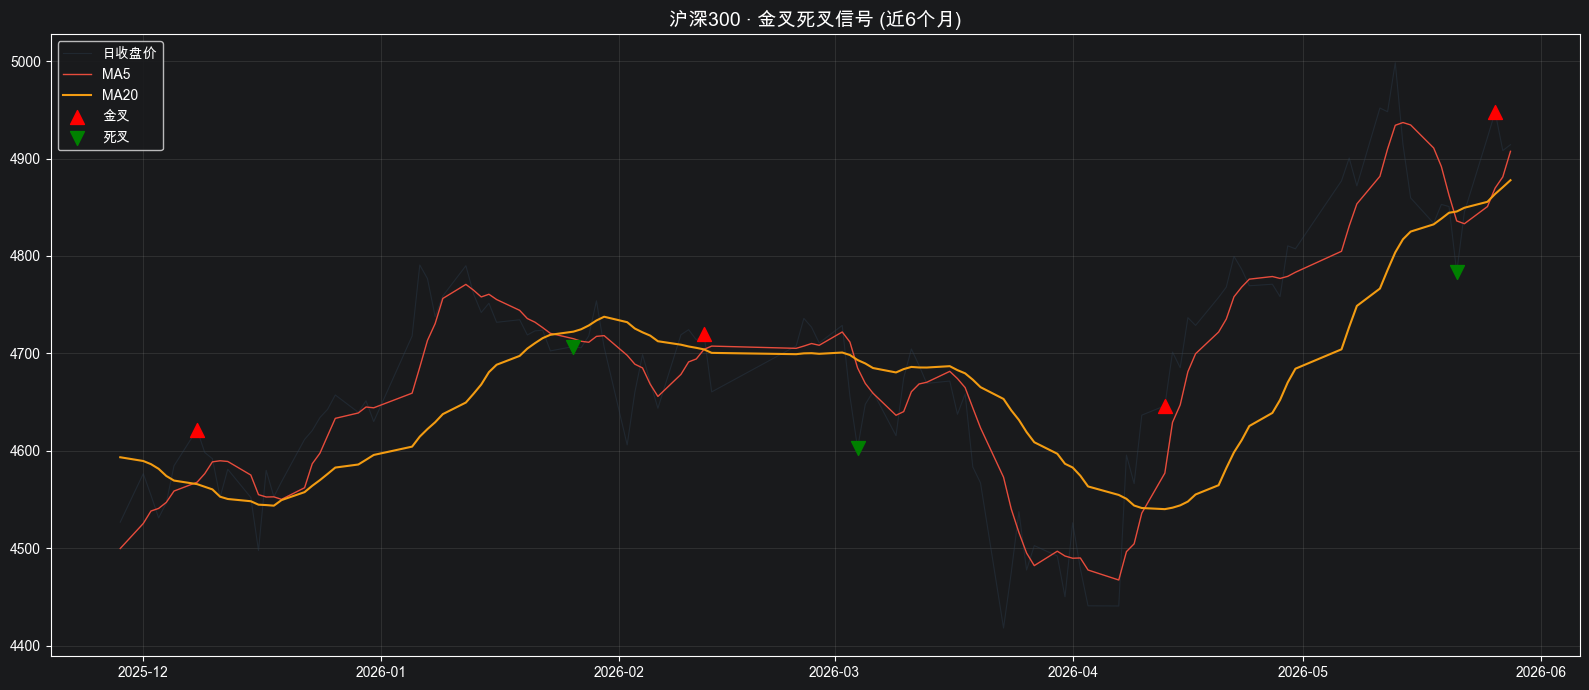

In [16]:
# 画出金叉死叉标注
# 只看最近 6 个月，否则太密集看不清
recent_6m = recent[recent.index >= recent.index[-1] - pd.DateOffset(months=6)]
golden_6m = recent_6m[recent_6m['golden_cross']]
death_6m = recent_6m[recent_6m['death_cross']]

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(recent_6m.index, recent_6m['close'], 
        color='#2c3e50', alpha=0.4, linewidth=0.8, label='日收盘价')
ax.plot(recent_6m.index, recent_6m['MA5'], 
        color='#e74c3c', linewidth=1, label='MA5')
ax.plot(recent_6m.index, recent_6m['MA20'], 
        color='#f39c12', linewidth=1.5, label='MA20')

# 标注金叉 🔼 和死叉 🔽
ax.scatter(golden_6m.index, golden_6m['close'], 
           color='red', marker='^', s=100, zorder=10, label='金叉')
ax.scatter(death_6m.index, death_6m['close'], 
           color='green', marker='v', s=100, zorder=10, label='死叉')

ax.set_title('沪深300 · 金叉死叉信号 (近6个月)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 5.8 小结

| 学到的技能 | ✓ |
|---|---|
| 用 AKShare 下载指数日线数据 | ☐ |
| 数据清洗：列名统一、日期索引、缺失值处理 | ☐ |
| 计算 5/20/60 日均线 | ☐ |
| 计算对数收益率 + 滚动标准差 + 年化波动率 | ☐ |
| 画均线叠加图，判断多头/空头排列 | ☐ |
| 画波动率图，感知市场情绪 | ☐ |
| 理解金叉/死叉的基本逻辑 | ☐ |

---

> 💡 **提示：** 金叉死叉只是均线策略的起点。实际量化策略还需要考虑：
> - 手续费和滑点
> - 止损和仓位管理
> - 回测验证（不要只看信号数量，要看收益曲线）
> - 避免过拟合（参数不能对着历史数据调优）

**下一讲预告：** 用真实策略做一次完整的回测。